# ScopeGuard — Option B: Raw-Scope Risk Model

This notebook has two parts:

1. **Build the Option B dataset** — convert the engineered-feature dataset into
   a raw multi-hot "bag of scopes" representation (one binary column per
   OAuth scope), so the model has to learn from the scopes themselves rather
   than from hand-engineered features.
2. **Train, validate, and explain a model** on that raw-scope representation,
   using a proper train / validation / test split and a SHAP explanation of
   one prediction.

Scope binarization uses `sklearn.preprocessing.MultiLabelBinarizer` throughout
— no hand-rolled one-hot logic.

In [1]:
from collections import Counter
import json
import os
import optuna
import copy
import random

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import MultiLabelBinarizer, OrdinalEncoder
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, accuracy_score, precision_score, recall_score,
)
from xgboost import XGBClassifier
import shap

import warnings
warnings.filterwarnings("ignore")

/Users/taylorland/Desktop/SURGE/scope-guard-dashboard/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

Shared constants used in notebook.

In [59]:
RANDOM_SEED = 42

SCOPE_COLUMN = "scope_urls"
OFFLINE_COLUMN = "persistence"        # 1 = offline / refresh token requested
TARGET_COLUMN = "risk_label"
ID_COLUMN = "combination_id"

RISK_ORDER = ["Low", "Medium", "High", "Critical"]

# Carried through Option B for traceability (not model inputs)
META_COLUMNS = ["combination_id", "source_category", "source_label", "scope_urls"]

# Engineered rubric features Option B deliberately does NOT give the model
ENGINEERED_FEATURES = [
    "data_sensitivity", "access_level", "persistence", "transitive_exposure",
    "scope_count", "cross_service_breadth", "has_restricted_scope",
]

# Three-way split proportions (train is whatever remains: 0.70)
VAL_SIZE = 0.15
TEST_SIZE = 0.15


INPUT_PATH = '../dataset_cleaning/outputs/scope_guard_dataset_cleaned.csv'
OUTPUT_PATH = "outputs/scope_guard_dataset_optionB.csv"
VOCAB_PATH = "outputs/scope_vocabulary.json"
REFERENCE_PATH = "outputs/optionB_engineered_reference.csv"
SERVICE_CATALOG_PATH = "../dataset_creation/outputs/scopes_by_service.json"

SERVICE_BINARIZER_PATH = 'outputs/service_binarizer.joblib'
SCOPE_BINARIZER_PATH = 'outputs/scope_binarizer.joblib'
MODEL_PATH = 'outputs/best_model.joblib'
X_TRAIN_PATH = 'outputs/X_train.csv'

CONFUSION_MATRIX_PATH = 'outputs/confusion_matrix.png'
MODEL_PERFORMANCE_METRICS_PATH = 'outputs/model_performance_metrics.png'
BEST_SHAP_SCOPE_EXPLANATION_PATH = 'outputs/best_shap_scope_explanation.png'
SECOND_BEST_SHAP_SCOPE_EXPLANATION_PATH = 'outputs/secondbest_shap_scope_explanation.png'



## Shared helpers

Two small, generic helpers used in notebook. Neither one binarizes
anything — that's handled by `MultiLabelBinarizer` wherever it's needed.

In [3]:
def split_scopes(cell):
    """Split a '; '-separated scope_urls cell into a clean list of scope URLs."""
    return [s.strip() for s in str(cell).split(";") if s.strip()]


def short_name(scope_url):
    """
    Turn a full scope URL into a short, readable name for columns/plots.
        https://www.googleapis.com/auth/gmail.send  ->  gmail.send
    Bare OIDC scopes (openid, profile, email) are returned unchanged.
    """
    url = scope_url.strip()
    if "/" not in url:
        return url
    name = url.rstrip("/").split("/")[-1]
    return name if name else url


def plot_y_distribution(y_data, title, risk_order):
    """Bar chart of label counts in a y-array, ordered by risk_order."""
    if y_data is None or len(y_data) == 0:
        print(f"No data to plot for {title}")
        return

    y_series = pd.Series(y_data).map(lambda x: risk_order[x])
    distribution = y_series.value_counts().reindex(risk_order).fillna(0)

    fig = plt.figure(figsize=(10, 7))
    sns.barplot(x=distribution.index, y=distribution.values, hue=distribution.index,
                palette="viridis", legend=False)
    plt.title(title, fontsize=20)
    plt.xlabel("Risk Label", fontsize=16)
    plt.ylabel("Count", fontsize=16)
    plt.xticks(fontsize=14, rotation=45, ha="right")
    plt.yticks(fontsize=14)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

---
## Train and explain the Option B model

Uses a proper **three-way split**:

| Split | Size | Purpose |
|---|---|---|
| Train | 70% | Model fitting; 5-fold CV runs here to pick the best model |
| Validation | 15% | Intermediate checks / tuning — safe to inspect freely |
| Test | 15% | Touched **exactly once**, at the end, on the single pre-committed model |

Model selection happens on the training set only, so the test rows never
influence which model gets chosen — otherwise the final "held-out" score
would be optimistic.

Each combination is encoded as a multi-hot vector: one binary column per
scope, one binary column per Google *service* (Gmail, Drive, ...), and an
`offline` flag. All of the binarization is done with `MultiLabelBinarizer` —
no hand-rolled vocabulary/index bookkeeping.

### 2.1 — Load the dataset and encode the target

Loaded 1834 rows from ../dataset_cleaning/outputs/scope_guard_dataset_cleaned.csv


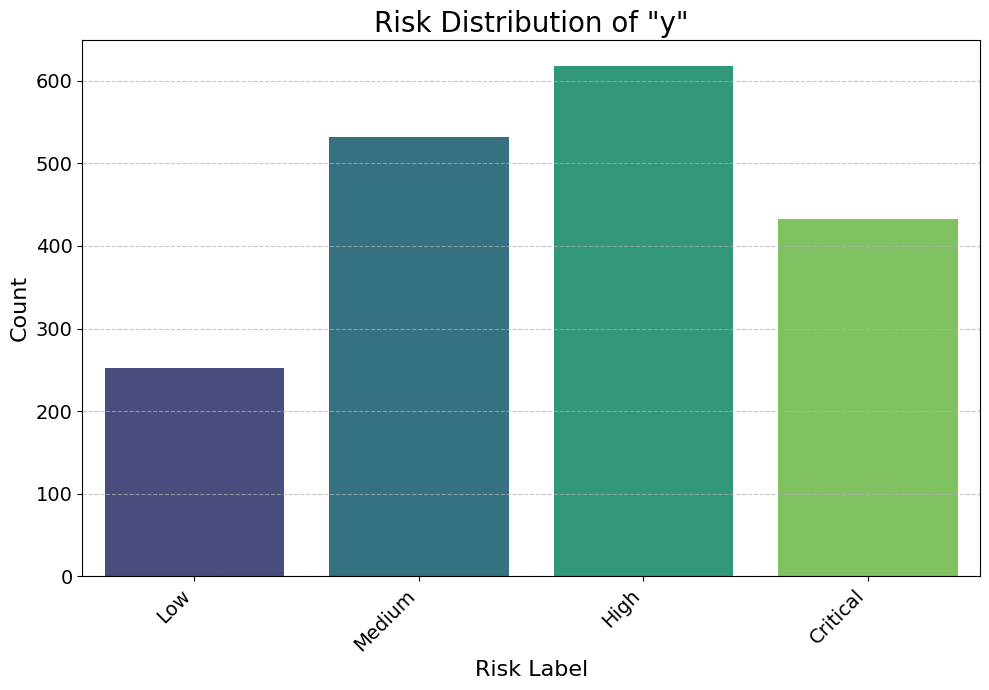

Label distribution:
  Low: 252 (13.7%)
  Medium: 532 (29.0%)
  High: 618 (33.7%)
  Critical: 432 (23.6%)


In [4]:
df = pd.read_csv(INPUT_PATH)
print(f"Loaded {len(df)} rows from {INPUT_PATH}")

# OrdinalEncoder needs a 2D, single-column input plus an explicit category
# order, so it pins Low=0, Medium=1, High=2, Critical=3 exactly (rather than
# picking up whatever order the labels happen to appear in the data).
label_encoder = OrdinalEncoder(categories=[RISK_ORDER], dtype=int)
y = label_encoder.fit_transform(df[[TARGET_COLUMN]]).ravel().astype(int)

plot_y_distribution(y, 'Risk Distribution of "y"', RISK_ORDER)

print("Label distribution:")
for tier in RISK_ORDER:
    n = (df[TARGET_COLUMN] == tier).sum()
    print(f"  {tier}: {n} ({n / len(df) * 100:.1f}%)")

### 2.2 — Build the feature matrix

Two `MultiLabelBinarizer`s: one over individual scopes, one over the
services those scopes belong to (from `scopes_by_service.json`), plus the
`offline` flag. This gives the model both a fine-grained (per-scope) and a
coarse-grained (per-service) view.

In [5]:
scope_lists = df[SCOPE_COLUMN].apply(split_scopes)

scope_binarizer = MultiLabelBinarizer()
scope_matrix = scope_binarizer.fit_transform(scope_lists)
scope_feature_names = [short_name(s) for s in scope_binarizer.classes_]
print(f"Scope vocabulary: {len(scope_binarizer.classes_)} distinct scopes")

#loading scopes by service
with open(SERVICE_CATALOG_PATH, encoding="utf-8") as f:
    service_catalog = json.load(f)

#creating key value pairs in form of {scope: service} for all scopes:
scope_to_service = {s.strip(): service for service, scopes in service_catalog.items() for s in scopes}

#ordering all serviceS:
services = sorted(service_catalog.keys())
print(f"{len(services)} services covering {len(scope_to_service)} scope URLs")

unmapped = {s for scopes in scope_lists for s in scopes if s not in scope_to_service}
if unmapped:
    print(f"  WARNING: {len(unmapped)} scopes not found in the service catalog "
          f"(no service flag set for them): {sorted(unmapped)}")

#creates a list of services for each scope combination that the combination accesses 
service_lists = scope_lists.apply(lambda scopes: [scope_to_service[s] for s in scopes if s in scope_to_service])
print(service_lists)
service_binarizer = MultiLabelBinarizer(classes=services)

#creating a one hot encoded array of services:
service_matrix = service_binarizer.fit_transform(service_lists)
service_feature_names = [f"svc:{s}" for s in services]

#checking if offline is present:
offline_flag = (df[OFFLINE_COLUMN].astype(str).str.strip() == "1").astype(np.int8).values.reshape(-1, 1)

#stacking the arrarys together side by side:
X = np.hstack([scope_matrix, service_matrix, offline_flag]).astype(np.int8)
feature_names = scope_feature_names + service_feature_names + ["offline"]

print(f"\nEncoded matrix: {X.shape[0]} rows x {X.shape[1]} columns ({(X == 0).mean() * 100:.1f}% zeros)")
print(f"  = {len(scope_feature_names)} scope cols + {len(service_feature_names)} service cols + offline")
print(scope_binarizer.classes_)


Scope vocabulary: 131 distinct scopes
27 services covering 131 scope URLs
0       [Identity, Identity, Identity, Fitness, Fitnes...
1          [Identity, Identity, Identity, YouTube, Drive]
2         [Identity, Identity, Identity, Contacts, Gmail]
3       [Identity, Identity, Identity, Cloud Storage, ...
4                  [Identity, Identity, Identity, Photos]
                              ...                        
1829                                        [Apps Script]
1830                                        [Apps Script]
1831                           [Apps Script, Apps Script]
1832                           [Apps Script, Apps Script]
1833                                             [Groups]
Name: scope_urls, Length: 1834, dtype: object

Encoded matrix: 1834 rows x 159 columns (96.2% zeros)
  = 131 scope cols + 27 service cols + offline
['email' 'https://mail.google.com/'
 'https://www.googleapis.com/auth/admin.datatransfer'
 'https://www.googleapis.com/auth/admin.directory.

### 2.3 — Dataset-level diagnostic: engineered vs. raw features

This is descriptive only — it runs on the **full** dataset and selects no
model. It just contrasts the engineered encoding (a near-lookup) with the
raw-scope encoding (a genuine learning task).

In [6]:
def compare_encodings(df, X_raw, y):
    eng_vectors = df[ENGINEERED_FEATURES].apply(tuple, axis=1).nunique()
    scope_sets = df[SCOPE_COLUMN].apply(lambda c: tuple(sorted(split_scopes(c)))).nunique()
    print(f"Unique engineered-feature vectors: {eng_vectors} / {len(df)} rows")
    print(f"Unique scope-sets:                 {scope_sets} / {len(df)} rows")
    print("(Few unique feature vectors => dense => lookup.\n"
          " Many unique scope-sets => sparse => genuine prediction.)")

    X_eng = df[ENGINEERED_FEATURES].values.astype(float)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
    diag_model = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                                random_state=RANDOM_SEED, eval_metric="mlogloss")

    f1_eng = cross_validate(diag_model, X_eng, y, cv=cv, scoring="f1_macro")["test_score"].mean()
    f1_raw = cross_validate(diag_model, X_raw, y, cv=cv, scoring="f1_macro")["test_score"].mean()
    print(f"\nXGBoost macro-F1, engineered features: {f1_eng:.3f}  (near-ceiling => lookup)")
    print(f"XGBoost macro-F1, raw scopes:          {f1_raw:.3f}  (real learning problem)")


compare_encodings(df, X, y)

Unique engineered-feature vectors: 502 / 1834 rows
Unique scope-sets:                 1649 / 1834 rows
(Few unique feature vectors => dense => lookup.
 Many unique scope-sets => sparse => genuine prediction.)

XGBoost macro-F1, engineered features: 0.983  (near-ceiling => lookup)
XGBoost macro-F1, raw scopes:          0.767  (real learning problem)


### 2.4 — Three-way split (70 / 15 / 15, stratified)

Split first, so model selection can never see the validation or test rows.

In [7]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=(VAL_SIZE + TEST_SIZE), stratify=y, random_state=RANDOM_SEED,
)
relative_test_size = TEST_SIZE / (VAL_SIZE + TEST_SIZE)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=relative_test_size, stratify=y_temp, random_state=RANDOM_SEED,
)

total = len(X)
print(f"{'Set':<12}{'Rows':>7}{'%':>8}   " + "".join(f"{t:>10}" for t in RISK_ORDER))
for name, yy in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    counts = [int((yy == i).sum()) for i in range(len(RISK_ORDER))]
    print(f"{name:<12}{len(yy):>7}{len(yy) / total * 100:>7.1f}%   " + "".join(f"{n:>10}" for n in counts))

print("\nThe TEST set is now locked. It is not touched again until section 2.6.")

Set            Rows       %          Low    Medium      High  Critical
Train          1283   70.0%          176       372       433       302
Validation      275   15.0%           38        80        92        65
Test            276   15.0%           38        80        93        65

The TEST set is now locked. It is not touched again until section 2.6.


### 2.5 — Model hyper parameter tuning

---
Every model is fit on the whole train data, tested on the validation, then tuned for 100 itterations. The best performing itteration (determined by macro f1) for each model is then taken to the next stage.

In [8]:
random.seed(RANDOM_SEED)
def objective(trial):
    params = {
        "objective": "multi:softprob",
        "num_class": 4,
        "eval_metric": "mlogloss",     # still needed for XGBoost's internal validation tracking
        "booster": "gbtree",
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", .05, 0.5, log=False),
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "gamma": trial.suggest_float("gamma", 1e-8, 1.0, log=True),
        "random_state" : RANDOM_SEED,
        'nthread':1
    }

    # Pruning still keys off mlogloss internally — F1 isn't computed per-round by XGBoost
    pruning_callback = optuna.integration.XGBoostPruningCallback(trial, "validation_0-mlogloss")

    # callbacks now go in the constructor, not fit() — required since XGBoost 2.1.0
    model = XGBClassifier(**params, callbacks=[pruning_callback])

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )

    preds = model.predict(X_val)               # class labels, not probabilities
    return f1_score(y_val, preds, average="macro")

sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)
study = optuna.create_study(direction="maximize", pruner=optuna.pruners.MedianPruner(),sampler=sampler)
study.optimize(objective, n_trials=100)

print("Best params:", study.best_params)
print("Best value:", study.best_value)
xgb_best_params = copy.deepcopy(study.best_params)
xgb_best_params['random_state'] = RANDOM_SEED
xgb_best_params['nthread'] = 1

[I 2026-08-06 13:33:41,634] A new study created in memory with name: no-name-298db563-d237-4640-b44c-80c2cfac9282
[I 2026-08-06 13:33:47,810] Trial 0 finished with value: 0.8069470658741982 and parameters: {'max_depth': 5, 'learning_rate': 0.4778214378844623, 'n_estimators': 759, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'min_child_weight': 2, 'reg_alpha': 3.3323645788192616e-08, 'reg_lambda': 0.6245760287469893, 'gamma': 0.0006440507553993703}. Best is trial 0 with value: 0.8069470658741982.
[I 2026-08-06 13:34:00,670] Trial 1 finished with value: 0.8162256010223641 and parameters: {'max_depth': 8, 'learning_rate': 0.0592630224331111, 'n_estimators': 973, 'subsample': 0.9162213204002109, 'colsample_bytree': 0.6061695553391381, 'min_child_weight': 2, 'reg_alpha': 4.4734294104626844e-07, 'reg_lambda': 5.472429642032198e-06, 'gamma': 0.00015777981883364995}. Best is trial 1 with value: 0.8162256010223641.
[I 2026-08-06 13:34:06,564] Trial 2 finished with va

Best params: {'max_depth': 9, 'learning_rate': 0.05156325559594452, 'n_estimators': 820, 'subsample': 0.6764154329979222, 'colsample_bytree': 0.5130627499794483, 'min_child_weight': 1, 'reg_alpha': 2.31474686980703e-07, 'reg_lambda': 1.5293803009834068e-06, 'gamma': 0.0001704967298121896}
Best value: 0.8310423236893826


In [9]:
def objective(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "max_features": trial.suggest_int("max_features", 6, 50),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20, log=False),
        "random_state": RANDOM_SEED
    }

    model = RandomForestClassifier(**params)

    model.fit(
        X_train, y_train,
    )

    preds = model.predict(X_val)               # class labels, not probabilities
    return f1_score(y_val, preds, average="macro")

sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)
study = optuna.create_study(direction="maximize",sampler=sampler)
study.optimize(objective, n_trials=100)

print("Best params:", study.best_params)
print("Best value:", study.best_value)
rf_best_params = copy.deepcopy(study.best_params)
rf_best_params['random_state'] = RANDOM_SEED

[I 2026-08-06 13:39:42,342] A new study created in memory with name: no-name-9298bb2a-628f-44e1-a79e-d9ffc1c90625
[I 2026-08-06 13:39:43,067] Trial 0 finished with value: 0.5135736803621083 and parameters: {'max_depth': 5, 'n_estimators': 956, 'max_features': 38, 'min_samples_split': 13, 'min_samples_leaf': 4}. Best is trial 0 with value: 0.5135736803621083.
[I 2026-08-06 13:39:43,174] Trial 1 finished with value: 0.5066434113121139 and parameters: {'max_depth': 4, 'n_estimators': 152, 'max_features': 44, 'min_samples_split': 13, 'min_samples_leaf': 15}. Best is trial 0 with value: 0.5135736803621083.
[I 2026-08-06 13:39:43,790] Trial 2 finished with value: 0.5018169376540178 and parameters: {'max_depth': 3, 'n_estimators': 973, 'max_features': 43, 'min_samples_split': 6, 'min_samples_leaf': 4}. Best is trial 0 with value: 0.5135736803621083.
[I 2026-08-06 13:39:44,022] Trial 3 finished with value: 0.5073572813896619 and parameters: {'max_depth': 4, 'n_estimators': 374, 'max_features':

Best params: {'max_depth': 10, 'n_estimators': 350, 'max_features': 50, 'min_samples_split': 9, 'min_samples_leaf': 4}
Best value: 0.7323598291437547


In [10]:
def objective(trial):
    params = {
     "C": trial.suggest_float("C",.5,3.0),
     'tol':trial.suggest_float('tol',1e-5,1e-3,log=True),
     'max_iter':trial.suggest_int('max_iter',50,250),
     "random_state": RANDOM_SEED
    }

    model = LogisticRegression(**params)

    model.fit(
        X_train, y_train,
    )

    preds = model.predict(X_val)               # class labels, not probabilities
    return f1_score(y_val, preds, average="macro")

sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)
study = optuna.create_study(direction="maximize",sampler=sampler)
study.optimize(objective, n_trials=100)

print("Best params:", study.best_params)
print("Best value:", study.best_value)
logreg_best_params = copy.deepcopy(study.best_params)
logreg_best_params['random_state'] = RANDOM_SEED

[I 2026-08-06 13:40:22,182] A new study created in memory with name: no-name-cf068772-732b-47cd-9227-bb6a4f0b7b5c
[I 2026-08-06 13:40:22,218] Trial 0 finished with value: 0.7843362063274902 and parameters: {'C': 1.4363502971184063, 'tol': 0.0007969454818643932, 'max_iter': 197}. Best is trial 0 with value: 0.7843362063274902.
[I 2026-08-06 13:40:22,316] Trial 1 finished with value: 0.7890313443048187 and parameters: {'C': 1.9966462104925915, 'tol': 2.0513382630874486e-05, 'max_iter': 81}. Best is trial 1 with value: 0.7890313443048187.
[I 2026-08-06 13:40:22,335] Trial 2 finished with value: 0.7316967663728491 and parameters: {'C': 0.6452090304204987, 'tol': 0.0005399484409787432, 'max_iter': 170}. Best is trial 1 with value: 0.7890313443048187.
[I 2026-08-06 13:40:22,392] Trial 3 finished with value: 0.7954800788927487 and parameters: {'C': 2.2701814444901136, 'tol': 1.0994335574766187e-05, 'max_iter': 244}. Best is trial 3 with value: 0.7954800788927487.
[I 2026-08-06 13:40:22,434] T

Best params: {'C': 2.966509879871155, 'tol': 0.00011563733945525297, 'max_iter': 247}
Best value: 0.813222199029775


### 2.6 -- Tuned Model Selection
----------
Tuned models are now intialized with their best performing tuned hyperparameters. They are then fit on the train set via 5 fold stratified CV. The two model types with the highest macro f1 across CV is then taken to the next stage.

In [37]:
candidate_models = {
    'XGBoost': XGBClassifier(**xgb_best_params),
    'RandomForrest': RandomForestClassifier(**rf_best_params),
    'LogisticRegression': LogisticRegression(**logreg_best_params)
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
cv_results = {}
for name, candidate in candidate_models.items():
    scores = cross_validate(candidate, X_train, y_train, cv=cv, scoring=["accuracy", "f1_macro"])
    cv_results[name] = {
        "accuracy": scores["test_accuracy"].mean(),
        "f1": scores["test_f1_macro"].mean(),
        "f1_std": scores["test_f1_macro"].std(),
    }
    print(f"{name}: accuracy={cv_results[name]['accuracy']:.3f}  "
          f"macro-F1={cv_results[name]['f1']:.3f} (+/- {cv_results[name]['f1_std']:.3f})")

best_name = max(cv_results, key=lambda n: cv_results[n]["f1"])
best_model = candidate_models[best_name]
print(f"\nSELECTED MODEL: {best_name} (CV macro-F1 = {cv_results[best_name]['f1']:.3f})")

del cv_results[best_name] #removing best performing model so we can also grab the second best model


second_best_name  = max(cv_results, key=lambda n: cv_results[n]["f1"])
second_best_model = candidate_models[second_best_name]

print(f"\nSECOND MODEL SELECTED: {second_best_name} (CV macro-F1 = {cv_results[second_best_name]['f1']:.3f})")

XGBoost: accuracy=0.783  macro-F1=0.785 (+/- 0.026)
RandomForrest: accuracy=0.709  macro-F1=0.685 (+/- 0.025)
LogisticRegression: accuracy=0.771  macro-F1=0.770 (+/- 0.033)

SELECTED MODEL: XGBoost (CV macro-F1 = 0.785)

SECOND MODEL SELECTED: LogisticRegression (CV macro-F1 = 0.770)


### 2.7 — Fit best two models on train,

We have selected our two best performing models, now we will train it on the whole train split before taking it to the test split.

In [38]:
best_model.fit(X_train, y_train)
second_best_model.fit(X_train, y_train)

print(best_name)
best_y_pred_val = best_model.predict(X_val)
print(f"Accuracy: {accuracy_score(y_val, best_y_pred_val):.3f}")
print(f"Macro-F1: {f1_score(y_val, best_y_pred_val, average='macro'):.3f}\n")
print(classification_report(y_val, best_y_pred_val, target_names=RISK_ORDER, zero_division=0))

print(second_best_name)
sbest_y_pred_val = second_best_model.predict(X_val)
print(f"Accuracy: {accuracy_score(y_val, sbest_y_pred_val):.3f}")
print(f"Macro-F1: {f1_score(y_val, sbest_y_pred_val, average='macro'):.3f}\n")
print(classification_report(y_val, sbest_y_pred_val, target_names=RISK_ORDER, zero_division=0))

XGBoost
Accuracy: 0.825
Macro-F1: 0.831

              precision    recall  f1-score   support

         Low       0.82      0.87      0.85        38
      Medium       0.81      0.74      0.77        80
        High       0.80      0.83      0.81        92
    Critical       0.88      0.91      0.89        65

    accuracy                           0.83       275
   macro avg       0.83      0.83      0.83       275
weighted avg       0.82      0.83      0.82       275

LogisticRegression
Accuracy: 0.804
Macro-F1: 0.813

              precision    recall  f1-score   support

         Low       0.86      0.84      0.85        38
      Medium       0.79      0.76      0.78        80
        High       0.77      0.77      0.77        92
    Critical       0.83      0.88      0.85        65

    accuracy                           0.80       275
   macro avg       0.81      0.81      0.81       275
weighted avg       0.80      0.80      0.80       275



### 2.7 — Final test evaluation

Touched exactly once, on the single already-committed model. These are the
numbers to report.

In [39]:
best_y_pred_test = best_model.predict(X_test)
sbest_y_pred_test = second_best_model.predict(X_test)

print(best_name)
print(f"Accuracy: {accuracy_score(y_test, best_y_pred_test)}")
print(f"Macro-F1: {f1_score(y_test, best_y_pred_test, average='macro')}\n")
print(classification_report(y_test, best_y_pred_test, target_names=RISK_ORDER, zero_division=0))

print(second_best_name)
print(f"Accuracy: {accuracy_score(y_test, sbest_y_pred_test)}")
print(f"Macro-F1: {f1_score(y_test, sbest_y_pred_test, average='macro')}\n")
print(classification_report(y_test, sbest_y_pred_test, target_names=RISK_ORDER, zero_division=0))

XGBoost
Accuracy: 0.8333333333333334
Macro-F1: 0.8422463875448472

              precision    recall  f1-score   support

         Low       0.82      0.95      0.88        38
      Medium       0.85      0.76      0.80        80
        High       0.77      0.85      0.81        93
    Critical       0.93      0.83      0.88        65

    accuracy                           0.83       276
   macro avg       0.84      0.85      0.84       276
weighted avg       0.84      0.83      0.83       276

LogisticRegression
Accuracy: 0.8152173913043478
Macro-F1: 0.817678902631225

              precision    recall  f1-score   support

         Low       0.77      0.87      0.81        38
      Medium       0.81      0.81      0.81        80
        High       0.79      0.81      0.80        93
    Critical       0.90      0.80      0.85        65

    accuracy                           0.82       276
   macro avg       0.82      0.82      0.82       276
weighted avg       0.82      0.82      0.

### 2.8 — Pick one test row to explain

In [40]:
rng = np.random.default_rng(RANDOM_SEED)
sample_idx = int(rng.integers(0, len(X_test)))
sample = X_test[sample_idx]

# getting preds for each model then mapping to class label
# .predict gives absoulte value, like 3, instead of probabilities like proba
best_predicted_class = int(best_model.predict(X_test[sample_idx:sample_idx + 1])[0])
best_predicted_label = RISK_ORDER[best_predicted_class]
second_best_predicted_class = int(second_best_model.predict(X_test[sample_idx:sample_idx + 1])[0])
second_best_predicted_label = RISK_ORDER[second_best_predicted_class]

scopes_present = [feature_names[i] for i in range(len(feature_names)) if sample[i] == 1.0]

print(f"Test row #{sample_idx}")
print(f"Scopes present: {', '.join(scopes_present)}")
print(f"{best_name} model prediction: {best_predicted_label}")
print(f"{second_best_name} model prediction: {second_best_predicted_label}")

Test row #24
Scopes present: calendar.acls, calendar.calendars.readonly, calendar.events, calendar.readonly, svc:Calendar
XGBoost model prediction: Medium
LogisticRegression model prediction: Medium


### 2.9 — Local SHAP explanation

Which scopes drove this particular prediction, for the top 10 by absolute
SHAP value.

In [ ]:
top_k = 10

if best_name in ("Random_Forest", "XGBoost"):
    explainer = shap.TreeExplainer(best_model)
elif best_name == "Logistic Regression":
    explainer = shap.LinearExplainer(best_model, X_train)
else:
    explainer = shap.Explainer(best_model, X_train)

shap_values = explainer.shap_values(X_test[sample_idx:sample_idx + 1])

# Multiclass-safe extraction of the predicted class slice
if isinstance(shap_values, list):
    shap_vals = shap_values[best_predicted_class][0]
elif np.ndim(shap_values) == 3:
    shap_vals = shap_values[0, :, best_predicted_class]
else:
    shap_vals = shap_values[0]

ranked = sorted(zip(feature_names, shap_vals, X_test[sample_idx]), key=lambda t: -abs(t[1]))[:top_k]

print(f"Top {top_k} scope contributions toward '{best_predicted_label}' for {best_name}:")
for name, val, present in ranked:
    arrow = "increases" if val > 0 else "decreases"
    tag = "present" if present == 1.0 else "absent"
    print(f"  {name:>32} ({tag:>7}): {val:+.3f} ({arrow} model confidence)")

Top 10 scope contributions toward 'Medium for XGBoost':
                   calendar.events (present): +1.164 (increases model confidence)
                     calendar.acls (present): +0.879 (increases model confidence)
                      svc:Calendar (present): -0.589 (decreases model confidence)
       calendar.calendars.readonly (present): +0.544 (increases model confidence)
                 calendar.readonly (present): +0.335 (increases model confidence)
                         svc:Gmail ( absent): +0.256 (increases model confidence)
             calendar.events.owned ( absent): -0.178 (decreases model confidence)
              calendar.app.created ( absent): -0.161 (decreases model confidence)
          calendar.events.readonly ( absent): -0.155 (decreases model confidence)
                calendar.calendars ( absent): -0.150 (decreases model confidence)


### 2.10 — Plot the SHAP explanation

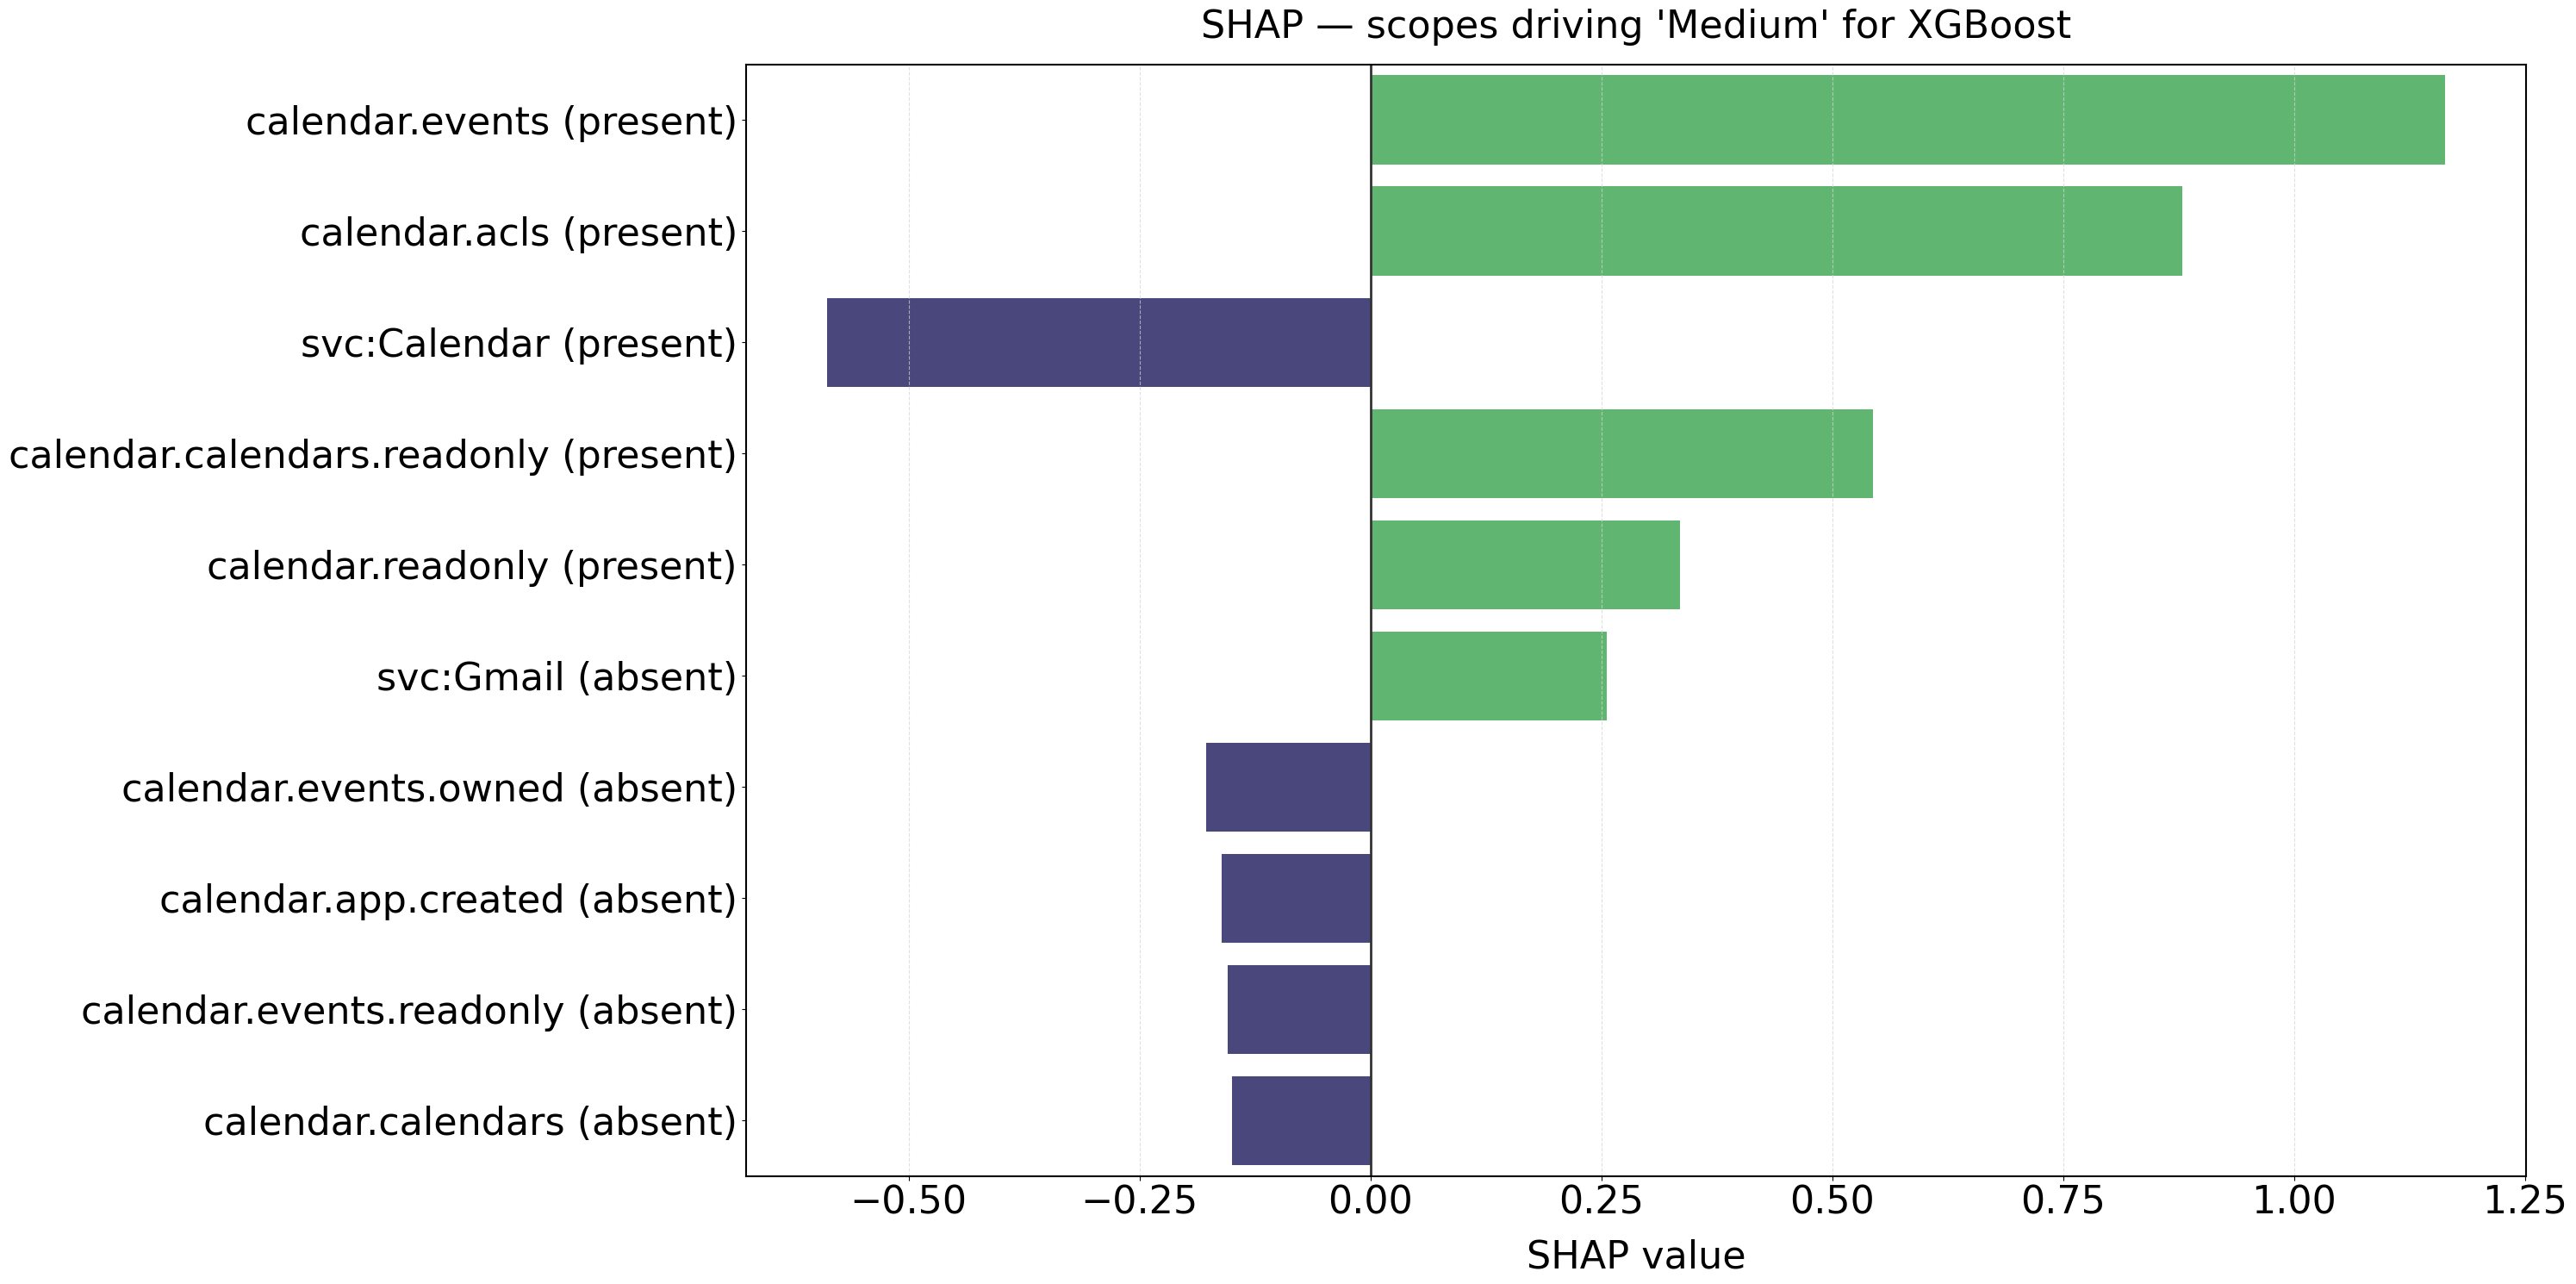

Saved: shap_scope_explanation.png to: outputs/shap_scope_explanation.png


In [ ]:
# Poster sizing: 10 horizontal bars with long labels at 32pt need a wide
# canvas, otherwise the y-labels eat the plotting area and squash the bars.
POSTER_FONTSIZE = 32
fig, ax = plt.subplots(figsize=(30, 15))

# `ranked` is already sorted by descending absolute SHAP value; seaborn draws
# the first category at the top, so passing it as-is puts the largest
# magnitude at the top regardless of sign.
names = [f"{t[0]} ({'present' if t[2] == 1.0 else 'absent'})" for t in ranked]
scores = [float(t[1]) for t in ranked]

viridis = sns.color_palette("viridis", n_colors=10)
pos_color, neg_color = viridis[7], viridis[1]
colors = [pos_color if s > 0 else neg_color for s in scores]

sns.barplot(x=scores, y=names, hue=names, palette=colors, dodge=False, legend=False, ax=ax, orient="h")
ax.set_yticks(np.arange(len(names)))
ax.set_yticklabels(names, fontsize=POSTER_FONTSIZE)
ax.tick_params(axis="x", labelsize=POSTER_FONTSIZE)
ax.axvline(0, color="#333", linewidth=2.0)
ax.set_xlabel("SHAP value", fontsize=POSTER_FONTSIZE, labelpad=14)
ax.set_title(f"SHAP — scopes driving '{best_predicted_label}' for {best_name}", fontsize=POSTER_FONTSIZE, pad=22)
ax.grid(axis="x", linestyle="--", alpha=0.7, color="lightgrey")
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

plt.tight_layout()
# dpi 300 for print; 150 looks soft when blown up to poster scale.
plt.savefig(BEST_SHAP_SCOPE_EXPLANATION_PATH, dpi=300, bbox_inches="tight") 
plt.show()
plt.close(fig)
print(f"Saved: shap_scope_explanation.png to: {BEST_SHAP_SCOPE_EXPLANATION_PATH}")

In [53]:
top_k = 10

if second_best_name in ("Random_Forest", "XGBoost"):
    explainer = shap.TreeExplainer(second_best_model)
elif best_name == "Logistic Regression":
    explainer = shap.LinearExplainer(second_best_model, X_train)
else:
    explainer = shap.Explainer(second_best_model, X_train)

shap_values = explainer.shap_values(X_test[sample_idx:sample_idx + 1])

# Multiclass-safe extraction of the predicted class slice
if isinstance(shap_values, list):
    shap_vals = shap_values[second_best_predicted_class][0]
elif np.ndim(shap_values) == 3:
    shap_vals = shap_values[0, :, second_best_predicted_class]
else:
    shap_vals = shap_values[0]

ranked = sorted(zip(feature_names, shap_vals, X_test[sample_idx]), key=lambda t: -abs(t[1]))[:top_k]

print(f"Top {top_k} scope contributions toward '{second_best_predicted_label} for {second_best_name}':")
for name, val, present in ranked:
    arrow = "increases" if val > 0 else "decreases"
    tag = "present" if present == 1.0 else "absent"
    print(f"  {name:>32} ({tag:>7}): {val:+.3f} ({arrow} model confidence)")

Top 10 scope contributions toward 'Medium for LogisticRegression':
                   calendar.events (present): +1.174 (increases model confidence)
                      svc:Calendar (present): -0.971 (decreases model confidence)
                     calendar.acls (present): +0.964 (increases model confidence)
                         svc:Gmail ( absent): +0.487 (increases model confidence)
       calendar.calendars.readonly (present): +0.465 (increases model confidence)
                           offline ( absent): +0.413 (increases model confidence)
                 calendar.readonly (present): -0.188 (decreases model confidence)
                      spreadsheets ( absent): +0.180 (increases model confidence)
                         svc:Admin ( absent): +0.133 (increases model confidence)
                    cloud-platform ( absent): +0.127 (increases model confidence)


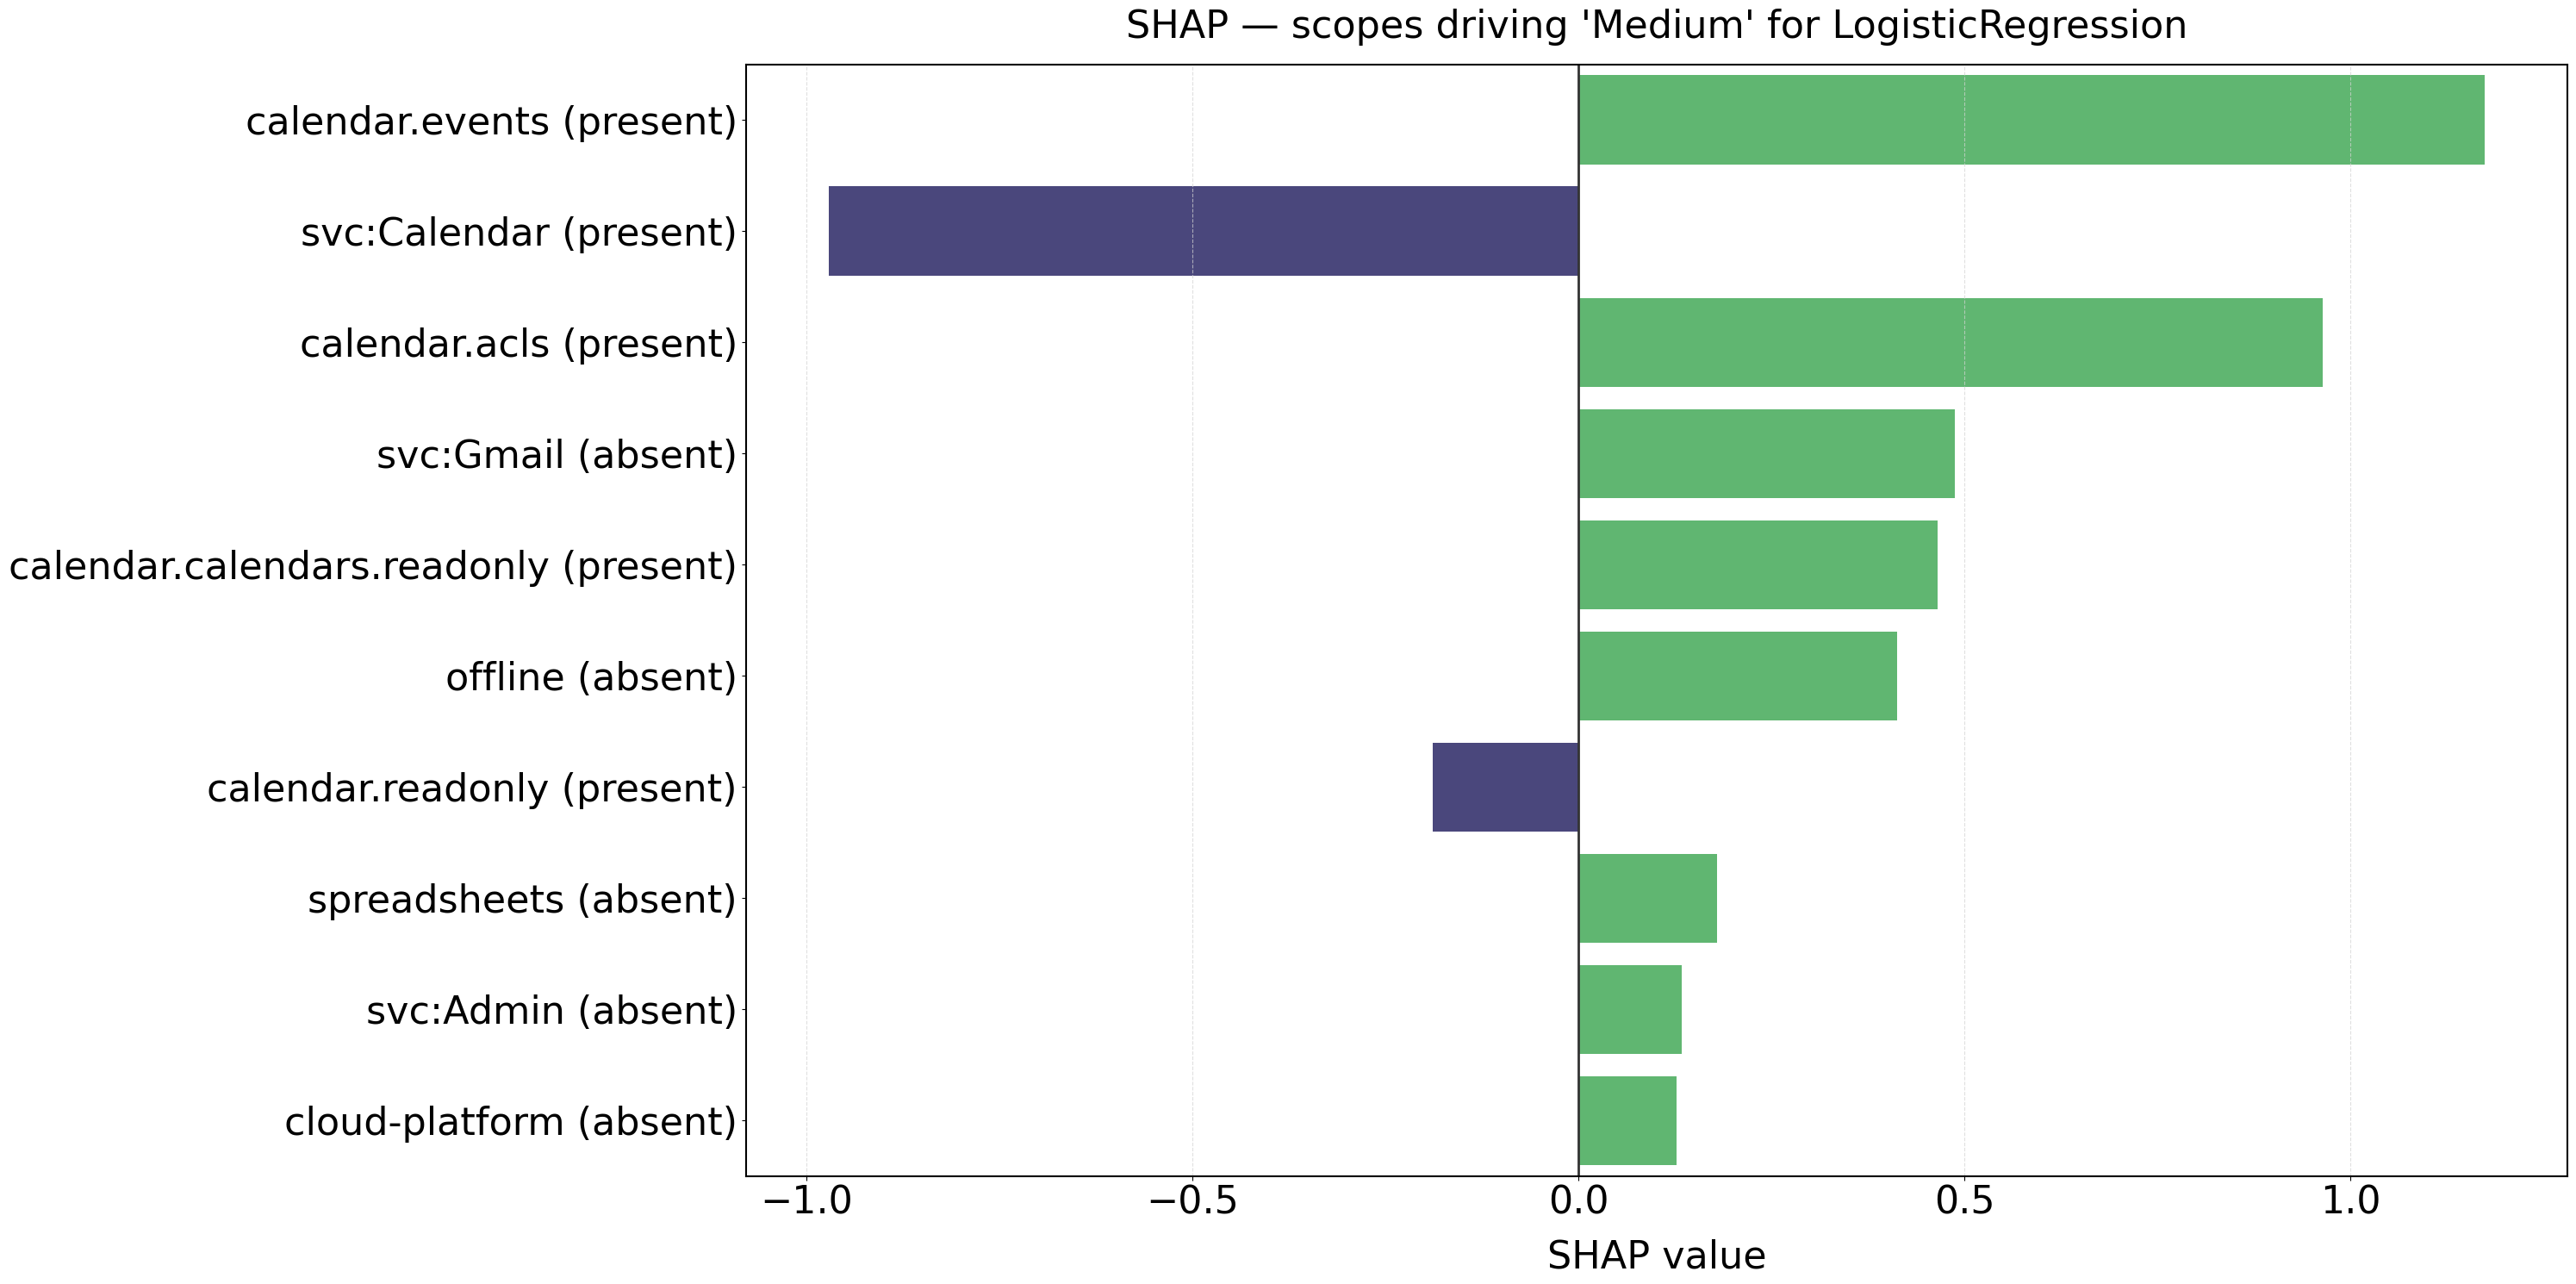

Saved: shap_scope_explanation.png to: outputs/shap_scope_explanation.png


In [ ]:
POSTER_FONTSIZE = 32
fig, ax = plt.subplots(figsize=(30, 15))

# `ranked` is already sorted by descending absolute SHAP value; seaborn draws
# the first category at the top, so passing it as-is puts the largest
# magnitude at the top regardless of sign.
names = [f"{t[0]} ({'present' if t[2] == 1.0 else 'absent'})" for t in ranked]
scores = [float(t[1]) for t in ranked]

viridis = sns.color_palette("viridis", n_colors=10)
pos_color, neg_color = viridis[7], viridis[1]
colors = [pos_color if s > 0 else neg_color for s in scores]

sns.barplot(x=scores, y=names, hue=names, palette=colors, dodge=False, legend=False, ax=ax, orient="h")
ax.set_yticks(np.arange(len(names)))
ax.set_yticklabels(names, fontsize=POSTER_FONTSIZE)
ax.tick_params(axis="x", labelsize=POSTER_FONTSIZE)
ax.axvline(0, color="#333", linewidth=2.0)
ax.set_xlabel("SHAP value", fontsize=POSTER_FONTSIZE, labelpad=14)
ax.set_title(f"SHAP — scopes driving '{second_best_predicted_label}' for {second_best_name}", fontsize=POSTER_FONTSIZE, pad=22)
ax.grid(axis="x", linestyle="--", alpha=0.7, color="lightgrey")
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    
plt.tight_layout()
# dpi 300 for print; 150 looks soft when blown up to poster scale.
plt.savefig(SECOND_BEST_SHAP_SCOPE_EXPLANATION_PATH, dpi=300, bbox_inches="tight") 
plt.show()
plt.close(fig)
print(f"Saved to: {SECOND_BEST_SHAP_SCOPE_EXPLANATION_PATH}")

### 2.11 — Model performance metrics

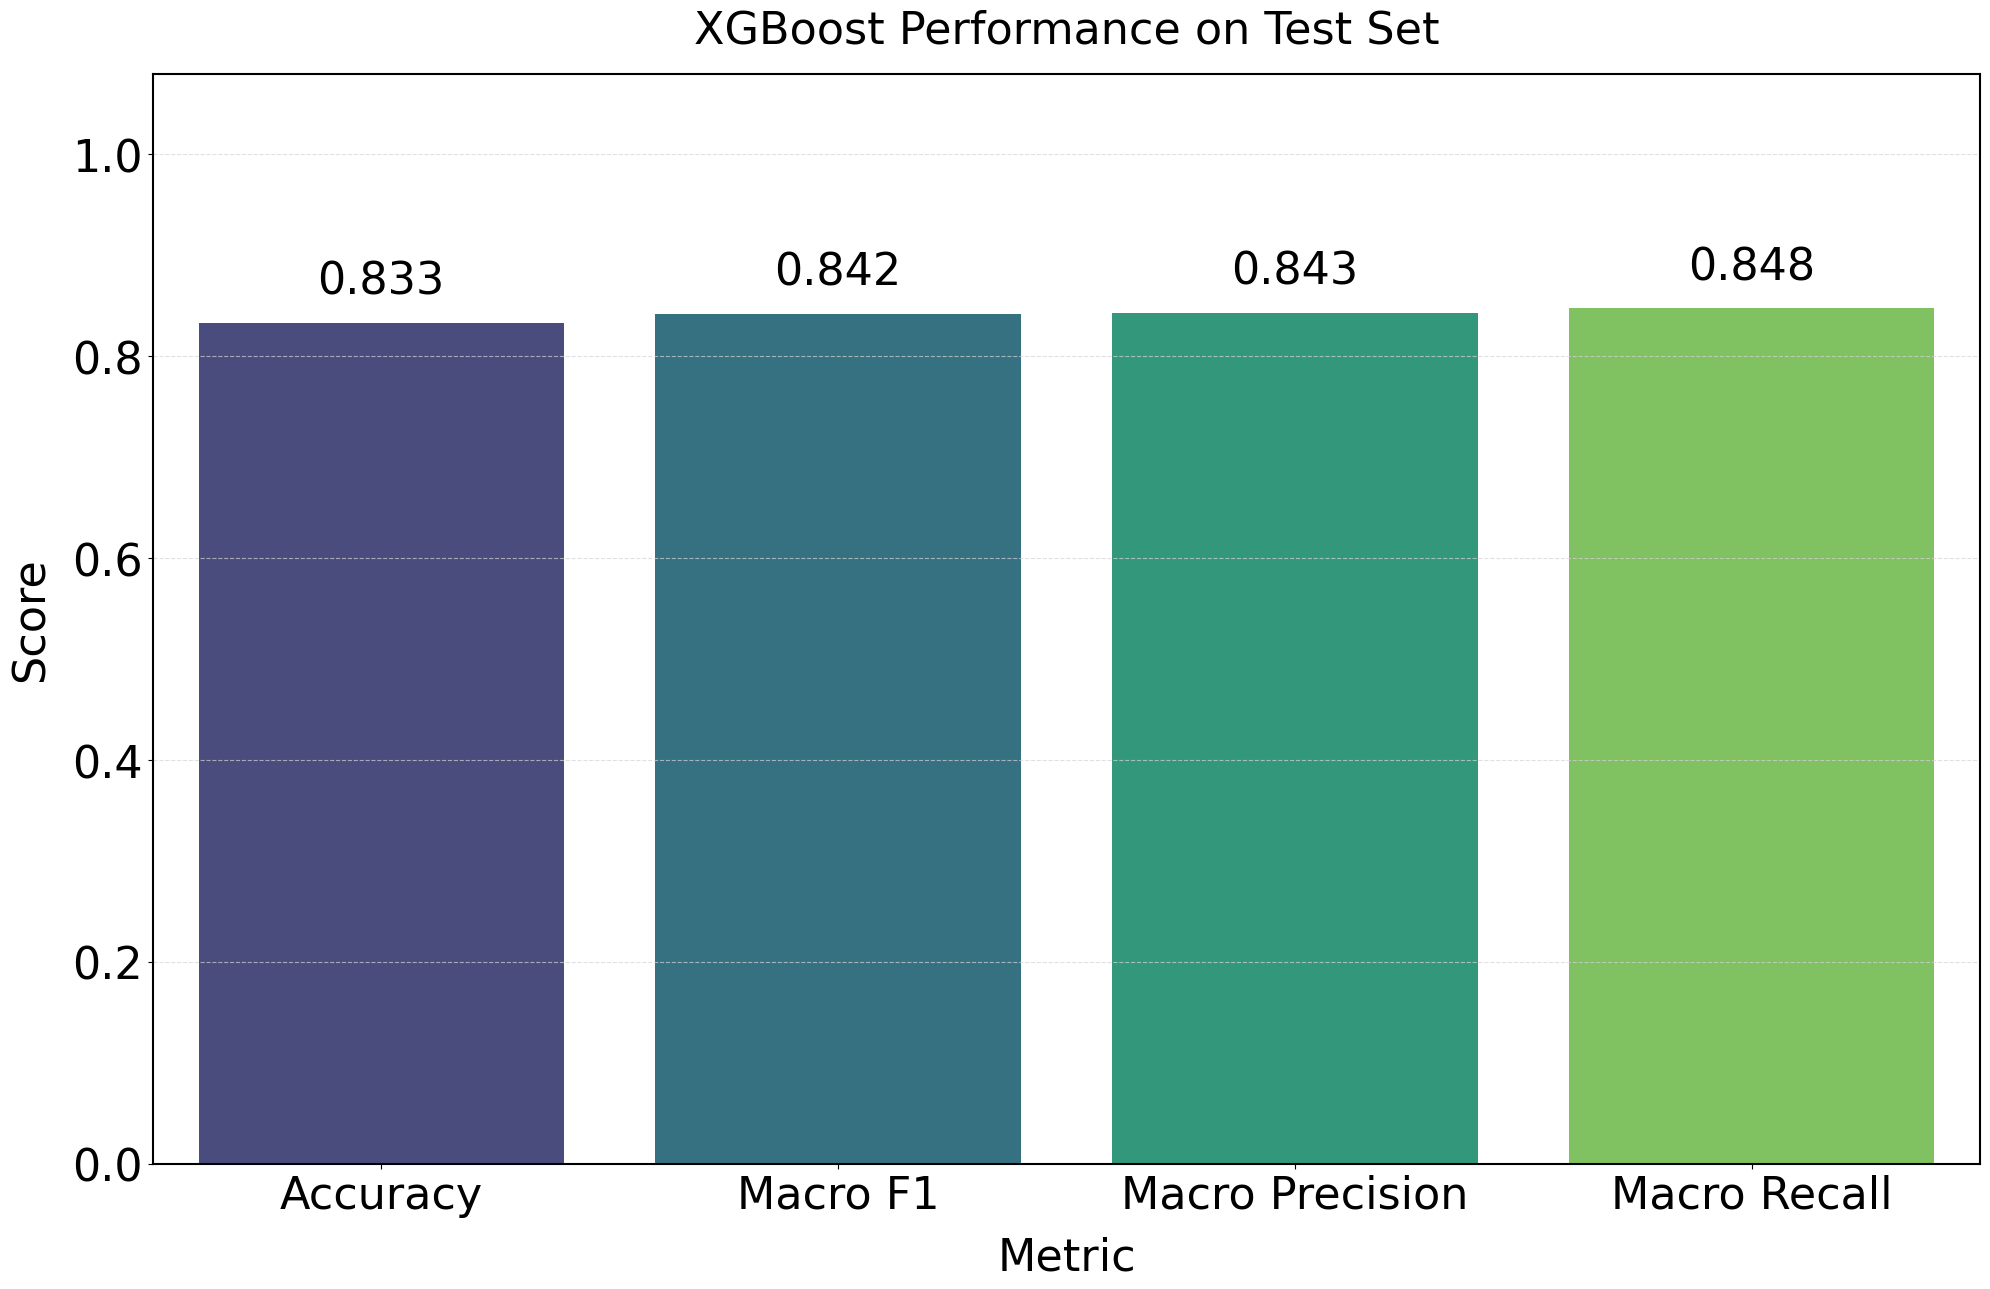

Saved: 'model_performance_metrics.png' to:outputs/model_performance_metrics.png 


In [55]:
accuracy = accuracy_score(y_test, best_y_pred_test)
f1_macro = f1_score(y_test, best_y_pred_test, average="macro", zero_division=0)
precision_macro = precision_score(y_test, best_y_pred_test, average="macro", zero_division=0)
recall_macro = recall_score(y_test, best_y_pred_test, average="macro", zero_division=0)

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Macro F1", "Macro Precision", "Macro Recall"],
    "Score": [accuracy, f1_macro, precision_macro, recall_macro],
})

POSTER_FONTSIZE = 32
fig, ax = plt.subplots(figsize=(20, 13))
sns.barplot(x="Metric", y="Score", data=metrics_df, hue="Metric", palette="viridis",
            dodge=False, legend=False, ax=ax)

ax.set_title(f"{best_name} Performance on Test Set", fontsize=POSTER_FONTSIZE, pad=22)
ax.set_xlabel("Metric", fontsize=POSTER_FONTSIZE, labelpad=14)
ax.set_ylabel("Score", fontsize=POSTER_FONTSIZE, labelpad=14)
ax.set_ylim(0, 1.08)  # headroom so the value labels aren't clipped
ax.tick_params(axis="x", labelsize=POSTER_FONTSIZE)
ax.tick_params(axis="y", labelsize=POSTER_FONTSIZE)
ax.grid(axis="y", linestyle="--", alpha=0.7, color="lightgrey")
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

for i, row in metrics_df.iterrows():
    ax.text(i, row["Score"] + 0.02, f"{row['Score']:.3f}", ha="center", va="bottom", fontsize=POSTER_FONTSIZE)

plt.tight_layout()
plt.savefig(MODEL_PERFORMANCE_METRICS_PATH, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"Saved: 'model_performance_metrics.png' to:{MODEL_PERFORMANCE_METRICS_PATH} ")

### 2.12 — Confusion matrix

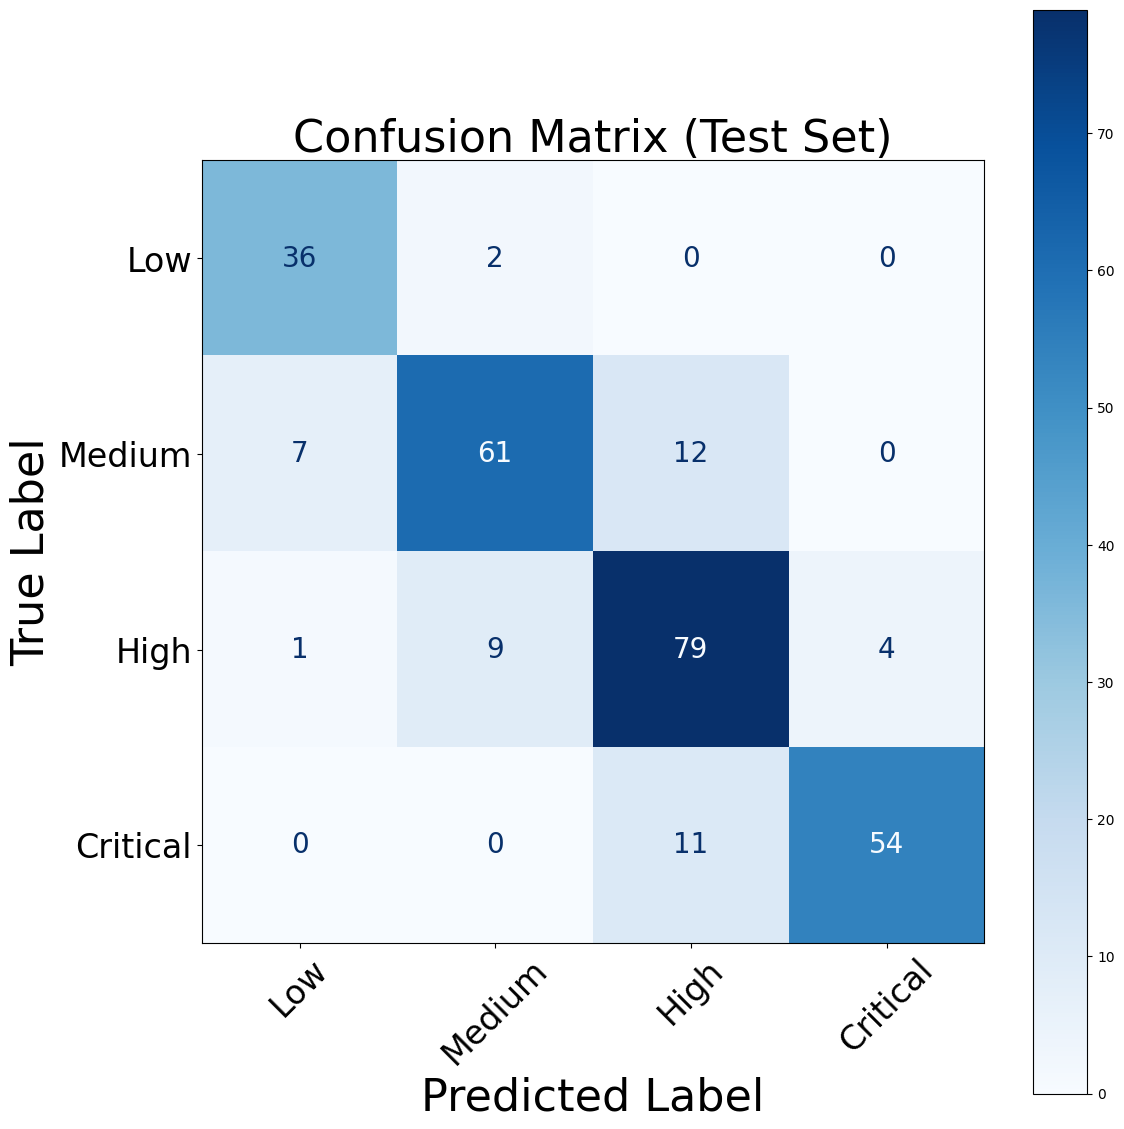

Saved: 'confusion_matrix.png' to: outputs/confusion_matrix.png


In [56]:
cm = confusion_matrix(y_test, best_y_pred_test, labels=np.arange(len(RISK_ORDER)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=RISK_ORDER)

fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format="d")

ax.set_title("Confusion Matrix (Test Set)", fontsize=32)
ax.set_xlabel("Predicted Label", fontsize=32)
ax.set_ylabel("True Label", fontsize=32)
ax.tick_params(axis="x", labelsize=24, rotation=45)
ax.tick_params(axis="y", labelsize=24, rotation=0)
for labels in disp.text_:
    for label in labels:
        label.set_fontsize(20)

plt.tight_layout()
plt.savefig(CONFUSION_MATRIX_PATH, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"Saved: 'confusion_matrix.png' to: {CONFUSION_MATRIX_PATH}")

### 2.13 — True label distribution in the test set

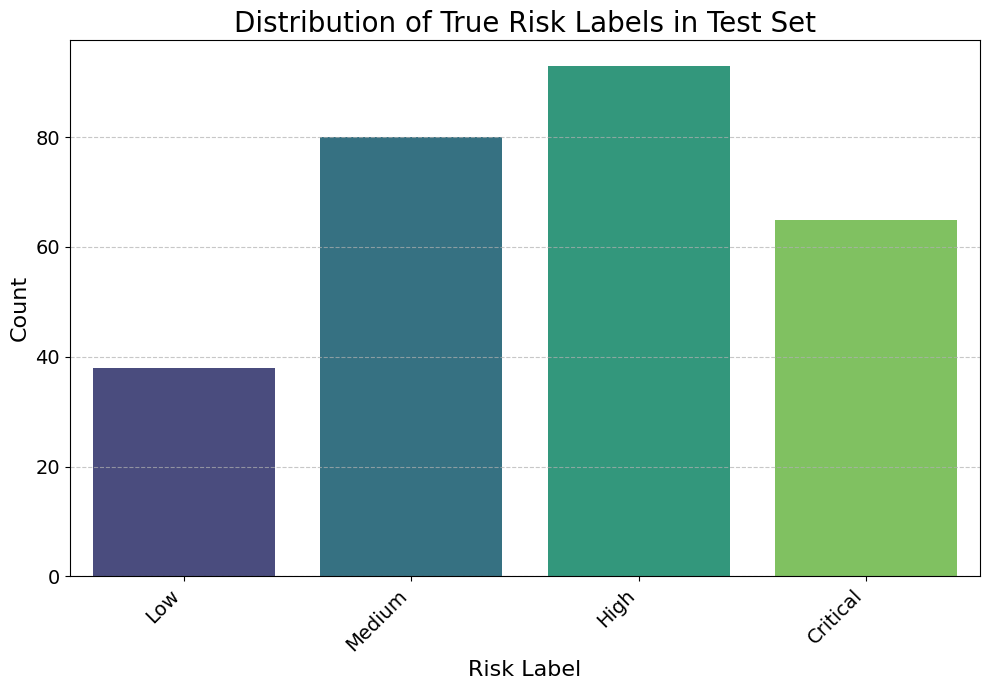

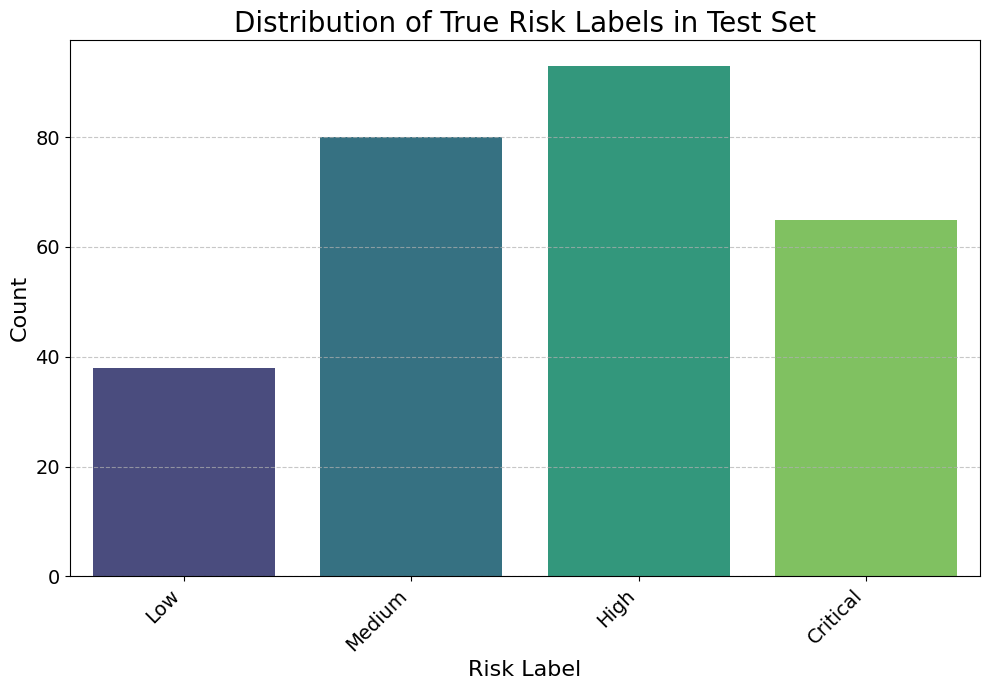

In [57]:
plot_y_distribution(y_test, "Distribution of True Risk Labels in Test Set", RISK_ORDER)

fig = plt.figure(figsize=(10, 7))
y_test_series = pd.Series(y_test).map(lambda x: RISK_ORDER[x])
distribution = y_test_series.value_counts().reindex(RISK_ORDER)
sns.barplot(x=distribution.index, y=distribution.values, hue=distribution.index,
            palette="viridis", legend=False)
plt.title("Distribution of True Risk Labels in Test Set", fontsize=20)
plt.xlabel("Risk Label", fontsize=16)
plt.ylabel("Count", fontsize=16)
plt.xticks(fontsize=14, rotation=45, ha="right")
plt.yticks(fontsize=14)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
#plt.savefig("y_test_distribution.png", dpi=150, bbox_inches="tight") uncomment to save
plt.show()
plt.close(fig)
#print("Saved: y_test_distribution.png")

### 2.14 — Save the model and supporting artifacts

In [58]:
joblib.dump(best_model, MODEL_PATH)
print(f"Trained model saved to {MODEL_PATH}")

joblib.dump(scope_binarizer, SCOPE_BINARIZER_PATH)
print(f"Binarizer saved to {SCOPE_BINARIZER_PATH}")

joblib.dump(service_binarizer, SERVICE_BINARIZER_PATH)
print(f"Binarizer saved to {SERVICE_BINARIZER_PATH}")

X_train_df = pd.DataFrame(X_train, columns=feature_names)
X_train_df.to_csv(X_TRAIN_PATH, index=False)

print("Saved X_train.csv")

Trained model saved to outputs/best_model.joblib
Binarizer saved to outputs/scope_binarizer.joblib
Binarizer saved to outputs/service_binarizer.joblib
Saved X_train.csv


In [21]:
print(len(scope_binarizer.classes_))

131
